## Double Homograohy On Chess Board

In [64]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import math
from sklearn.cluster import KMeans
import numpy as np
from sklearn.cluster import DBSCAN
import itertools


### Preprocessing Image

In [65]:

def resize_image(img, max_width=1024):
    """
    Resizes image to a maximum width of 10024 pixels, maintaining aspect ratio.
    """
    h, w = img.shape[:2]
    if w > max_width:
        scale = max_width / float(w)
        return cv2.resize(img, (int(w*scale), int(h*scale)))
    return img

def show_image_debug(title, img, points=None, Hlines=None, Vlines=None, treat_lines_as_infinite=False, size=7):
    """
    Display an image during processing with optional overlays. 
    It now expects Hlines/Vlines to be in the robust (N, 4) format: [x1, y1, x2, y2].
    """
    display_img = img.copy()
    h, w = display_img.shape[:2]

    def draw_lines(lines, color, treat_infinite=False):
        if lines is None: return
        # Ensure lines is an N x 4 array and handle empty arrays
        lines = np.atleast_2d(lines) 
        if lines.size == 0: return
            
        for line in lines:
            x1, y1, x2, y2 = line.astype(int) 
            if treat_infinite:
                if abs(x2 - x1) < 1:
                    cv2.line(display_img, (x1, 0), (x1, h), color, 2)
                    continue
                slope = (y2 - y1) / (x2 - x1)
                intercept = y1 - slope * x1
                if abs(y2 - y1) < 1:
                    cv2.line(display_img, (0, y1), (w, y1), color, 2)
                    continue
                y_start = int(slope * 0 + intercept)
                y_end = int(slope * w + intercept)
                cv2.line(display_img, (0, y_start), (w, y_end), color, 2)
            else:
                cv2.line(display_img, (x1, y1), (x2, y2), color, 2)

    draw_lines(Hlines, (0, 255, 0), treat_lines_as_infinite)
    
    draw_lines(Vlines, (255, 0, 0), treat_lines_as_infinite)
    
    
    plt.figure(figsize=(size, size))

    if len(display_img.shape) == 3:
        plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(display_img, cmap='gray')
    if points is not None:
        pts = np.array(points)
        plt.scatter(pts[:, 0], pts[:, 1], c='red', s=30)

    plt.title(title)
    plt.axis('off')
    plt.show()

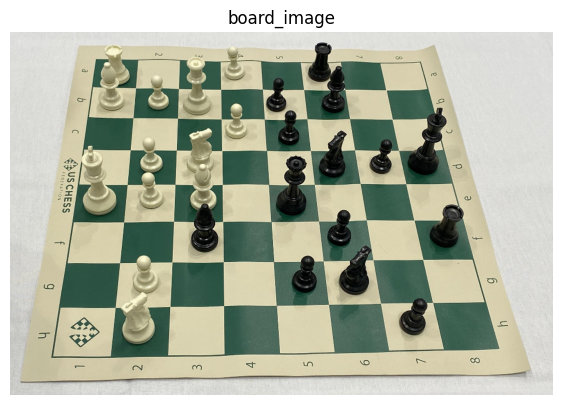

In [66]:
src_path = 'boards/board.jpg'
#src_path = 'boards/board0.jpg'
#reading image
image = cv2.imread(src_path)
#resozing for max length
image = resize_image(image)
#display image
show_image_debug("board_image", image)

In [67]:


def pre_processing_pipeline(img, threshold1=50, threshold2=70, dil_iter=1):
    #applying grayscale
    output = img.copy()
    if len(img.shape) == 3: output = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #applying gaussian blur
    output = cv2.GaussianBlur(output, (5, 5), 0)
    #canny edge detector
    #process = cv2.Canny(process, 50, 70)
    output = cv2.Canny(output, threshold1, threshold2)
    #dilation
    output = cv2.dilate(output, None, iterations=1) 

    return output


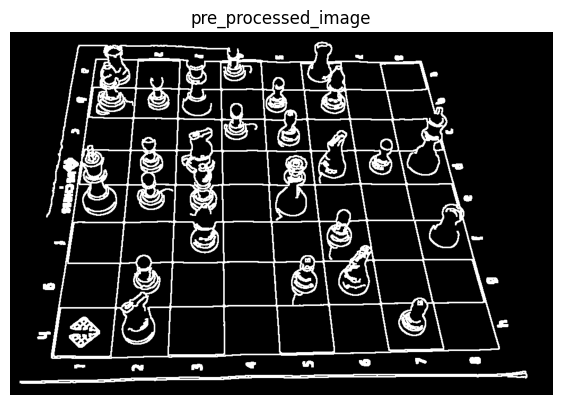

In [68]:
processes_image = pre_processing_pipeline(image, threshold1=10, threshold2=200)
show_image_debug("pre_processed_image", processes_image)

### Detecting Lines Image

In [69]:
def detect_lines(img, hough_threshold=50, min_line_length=50, max_line_gap=20):
    """
    Detects line segments using HoughLinesP and returns them in the 
    desired (N, 4) format: [x1, y1, x2, y2].
    """
    lines = cv2.HoughLinesP(
        img, 
        2, 
        np.pi/180, 
        threshold=hough_threshold, 
        minLineLength=min_line_length, 
        maxLineGap=max_line_gap
    )    
    if lines is not None:
        return lines.reshape(-1, 4)
    else:
        return np.array([], dtype=np.int32).reshape(0, 4)


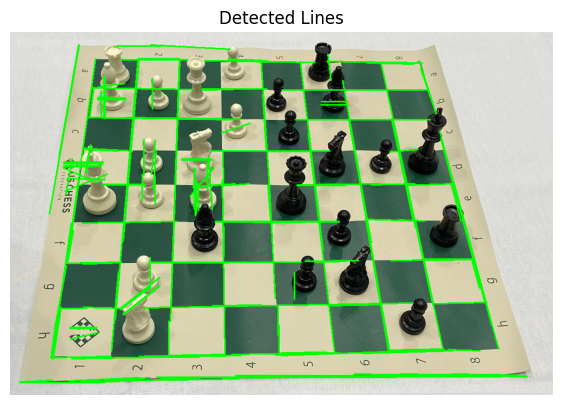

In [70]:
lines = detect_lines(processes_image, hough_threshold=100, min_line_length=50, max_line_gap=5)
show_image_debug("Detected Lines", image, Hlines=lines)

In [71]:
def visualize_dbscan_clusters(angles_deg, labels, title="DBSCAN Clustering of Line Angles"):
    """
    Creates a scatter plot of line angles colored by their DBSCAN cluster label.

    Args:
        angles_deg (np.array): 1D array of normalized line angles in degrees [0, 180).
        labels (np.array): 1D array of cluster labels assigned by DBSCAN.
        title (str): Title for the plot.
    """
    unique_labels = set(labels)
    n_clusters_ = len(unique_labels) - (1 if -1 in labels else 0)
    plt.figure(figsize=(10, 5))
    # Define color map for clusters
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    # Iterate over unique labels (-1 is noise)
    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Black used for noise.
            col = [0, 0, 0, 1]
            marker = 'x'
            s_size = 30
        else:
            marker = 'o'
            s_size = 50

        # Create a mask for the points belonging to the current cluster k
        class_member_mask = (labels == k)
        # Plot the points (angles) belonging to the cluster
        # We plot them on y=1 for a 1D visualization
        xy = angles_deg[class_member_mask]
        # Plot only the angles
        plt.scatter(xy, 
                    np.ones_like(xy), # Set all Y values to 1 for a single line plot
                    marker=marker, 
                    s=s_size, 
                    c=[col], 
                    label=f'Cluster {k}' if k != -1 else 'Noise',
                    zorder=3 # Ensure points are above grid
                   )
    plt.title(f'{title} (Estimated Clusters: {n_clusters_})')
    plt.xlabel('Normalized Line Angle (Degrees) [0° to 180°]')
    plt.yticks([]) # Remove Y-axis ticks since the plot is 1D
    plt.xlim(0, 180)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.legend(loc='upper right')
    plt.show()

In [72]:
def robust_chessboard_lines(lines, num_lines=4, angle_tolerance_deg=10, min_samples=3):
    """
    Clusters detected line segments into horizontal and vertical groups, 
    removes outliers using DBSCAN on angles, and selects the top 'num_lines' 
    based on line length.

    Args:
        num_lines (int): The number of top lines to select for each category.
        angle_tolerance_deg (float): The maximum angle difference (epsilon) for DBSCAN clustering, in degrees.
        min_samples (int): The minimum number of lines to form a cluster (DBSCAN).
    """
    if lines.shape[0] == 0: return np.array([]), np.array([])

    #get all dx dy
    dx = lines[:, 2] - lines[:, 0]
    dy = lines[:, 3] - lines[:, 1]
    # Calculate angles
    angles_rad = np.arctan2(dy, dx)
    angles_rad_normalized = angles_rad % np.pi
    angles_deg_normalized = np.degrees(angles_rad_normalized)
    X = angles_deg_normalized.reshape(-1, 1)
    # Calculate lengths
    lengths = np.sqrt(dx**2 + dy**2)
    
    # 2. Robust Clustering and Outlier Removal with DBSCAN    
    db = DBSCAN(eps=angle_tolerance_deg, min_samples=min_samples, metric='euclidean').fit(X)
    labels = db.labels_
    visualize_dbscan_clusters(angles_deg_normalized, labels)

    # Find the indices of the two largest clusters (Horizontal and Vertical)
    unique_labels = set(labels)
    cluster_labels = [l for l in unique_labels if l != -1] # Exclude noise
    
    if len(cluster_labels) < 2:
        print("Could not find two distinct clusters (Horizontal and Vertical). Returning all lines labeled as a cluster.")
        
        if len(cluster_labels) == 0:
             return np.array([]), np.array([])
             
        only_cluster_indices = np.where(labels == cluster_labels[0])[0]
        mean_angle = np.mean(angles_deg_normalized[only_cluster_indices])
        if np.abs(mean_angle - 90) < 45:
             return lines[only_cluster_indices], np.array([])
        else:
             return np.array([]), lines[only_cluster_indices]

    cluster_counts = {l: np.sum(labels == l) for l in cluster_labels}
    top_two_clusters = sorted(cluster_counts, key=cluster_counts.get, reverse=True)[:2]

    cluster_1_indices = np.where(labels == top_two_clusters[0])[0]
    cluster_2_indices = np.where(labels == top_two_clusters[1])[0]

    mean_angle_1 = np.mean(angles_deg_normalized[cluster_1_indices])
    mean_angle_2 = np.mean(angles_deg_normalized[cluster_2_indices])
    
    dist_to_90_1 = np.abs(mean_angle_1 - 90)
    dist_to_90_2 = np.abs(mean_angle_2 - 90)

    if dist_to_90_1 < dist_to_90_2:
        vertical_indices = cluster_1_indices
        horizontal_indices = cluster_2_indices
    else:
        vertical_indices = cluster_2_indices
        horizontal_indices = cluster_1_indices

    # 4. Line Selection: Ranking by Length
    def select_top_lines(indices, num_lines_limit):
        """Ranks lines by length and selects the top 'num_lines_limit'."""
        if len(indices) == 0:
            return np.array([])
            
        cluster_lines = lines[indices]
        cluster_lengths = lengths[indices]
        # 1. Get indices sorted by length (descending)
        sorted_indices_in_cluster = np.argsort(cluster_lengths)[::-1]
        
        # 2. Determine the actual number of lines to select:
        # We take the MINIMUM of the requested limit and the available lines.
        # This is a safe guard.
        num_to_select = min(num_lines_limit, len(sorted_indices_in_cluster))
        
        # 3. Select the top indices using the calculated limit
        top_indices = sorted_indices_in_cluster[:num_to_select] 
        
        # 4. Return the selected lines
        return cluster_lines[top_indices]


    top_vertical_lines = select_top_lines(vertical_indices,num_lines_limit=num_lines)
    top_horizontal_lines = select_top_lines(horizontal_indices,num_lines_limit=num_lines)

    return top_vertical_lines, top_horizontal_lines

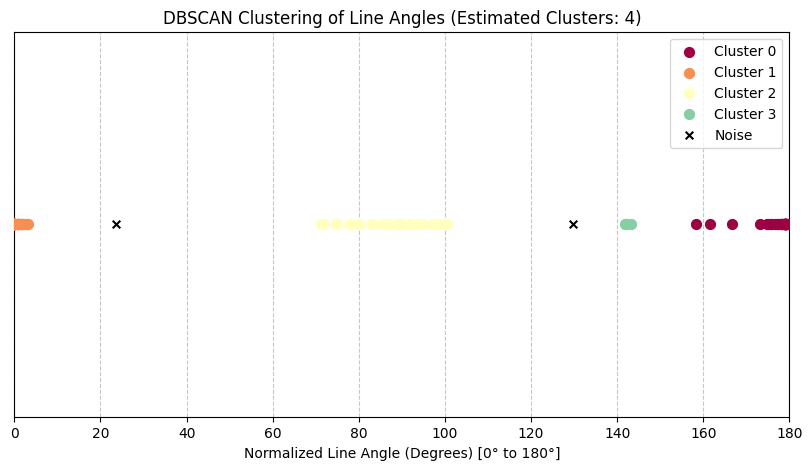

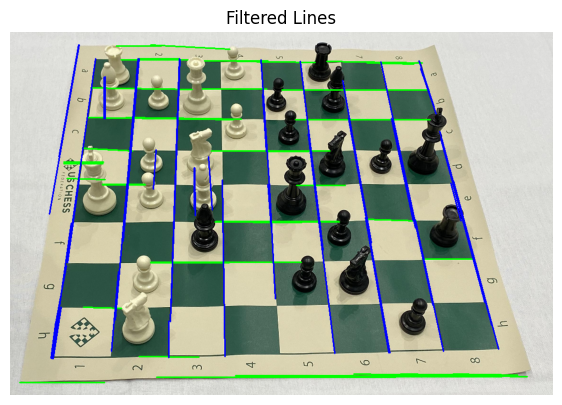

In [73]:
vertical_lines, horizontal_lines = robust_chessboard_lines(lines, num_lines=40, angle_tolerance_deg=10, min_samples=2)
show_image_debug("Filtered Lines", image, Hlines=horizontal_lines, Vlines=vertical_lines)

### Calculating Intersection And Applying First Homography

In [74]:
def compute_intersection(line1, line2):
    """
    Finds the intersection of two lines given in (x1, y1, x2, y2) format.
    Uses the cross product method (homogeneous coordinates).
    """
    # 1. Extract coordinates and force float to avoid integer overflow
    x1, y1, x2, y2 = map(float, line1)
    x3, y3, x4, y4 = map(float, line2)

    # 2. Compute the homogenous line representations
    # Line 1 passes through p1 and p2
    L1 = np.cross([x1, y1, 1], [x2, y2, 1])
    # Line 2 passes through p3 and p4
    L2 = np.cross([x3, y3, 1], [x4, y4, 1])

    # 3. The intersection point is the cross product of the two lines
    intersection = np.cross(L1, L2)

    # 4. Normalize (convert back from homogeneous to cartesian)
    if intersection[2] == 0:
        return None # Lines are parallel
    
    x = intersection[0] / intersection[2]
    y = intersection[1] / intersection[2]
    
    return [x, y]

In [75]:
def get_4_points(h_lines, v_lines):
    # Sort Horizontal lines by Y
    h_lines = sorted(h_lines, key=lambda l: (l[1] + l[3]) / 2)
    # Sort Vertical lines by X
    v_lines = sorted(v_lines, key=lambda l: (l[0] + l[2]) / 2)

    top_line = h_lines[0]
    bottom_line = h_lines[-1]
    left_line = v_lines[0]
    right_line = v_lines[-1]
    p_tl = compute_intersection(top_line, left_line)
    p_tr = compute_intersection(top_line, right_line)
    p_br = compute_intersection(bottom_line, right_line)
    p_bl = compute_intersection(bottom_line, left_line)    
    print("--- Intersection Debug ---")
    print(f"Top-Left:     {p_tl}")
    print(f"Top-Right:    {p_tr}")
    print(f"Bottom-Right: {p_br}")
    print(f"Bottom-Left:  {p_bl}")
    src_points = np.float32([p_tl, p_tr, p_br, p_bl])
    return src_points
    
def warp_to_chessboard_plane(image, inter_points, output_size=(640, 640), padding_pct=0.2):
    # --- Step 3: Define Destination Points ---
    # We map these to a square in the new image, but with PADDING 
    # so we don't cut off the rest of the board.
    
    w, h = output_size
    pad_w = w * padding_pct
    pad_h = h * padding_pct
    
    # Define the box inside the destination image where the detected grid will go
    dst_points = np.float32([
        [pad_w, pad_h],         # Top-Left
        [w - pad_w, pad_h],     # Top-Right
        [w - pad_w, h - pad_h], # Bottom-Right
        [pad_w, h - pad_h]      # Bottom-Left
    ])

    # --- Step 4: Compute Homography and Warp ---
    # Calculate the Homography Matrix
    M = cv2.getPerspectiveTransform(inter_points, dst_points)
    
    # Warp the image
    warped_img = cv2.warpPerspective(image, M, output_size)
    
    return warped_img, M



--- Intersection Debug ---
Top-Left:     [153.82608695652175, 26.0]
Top-Right:    [767.6246056782335, 26.0]
Bottom-Right: [937.8927444794953, 661.0]
Bottom-Left:  [71.0, 661.0]


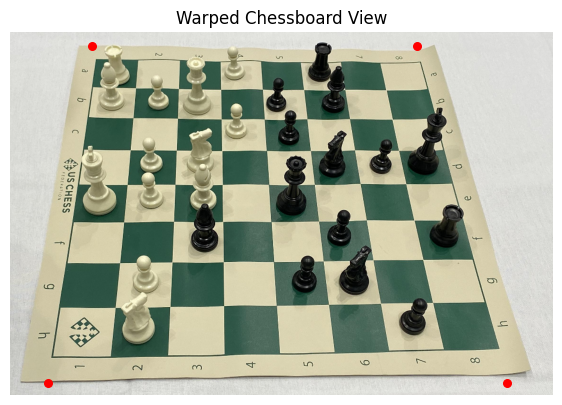

In [76]:
corner_pts = get_4_points(horizontal_lines, vertical_lines)
show_image_debug("Warped Chessboard View", image,points=corner_pts)

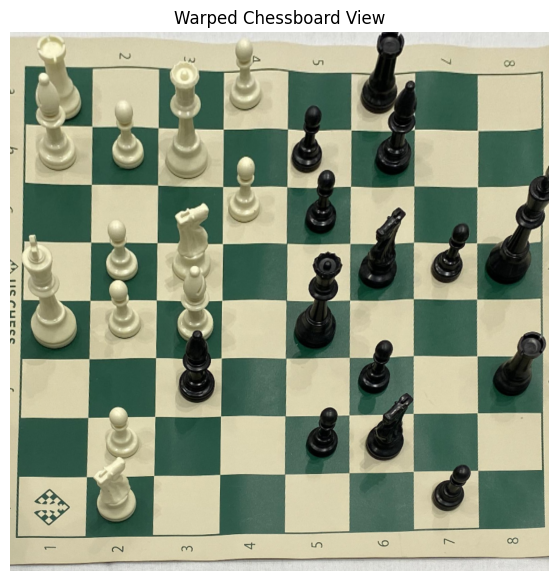

In [77]:
wrapped_image, H = warp_to_chessboard_plane(image, corner_pts, output_size=(1024, 1024), padding_pct=0.01)
show_image_debug("Warped Chessboard View", wrapped_image)

### Second Homography

In [78]:
def split_lines_hv(lines, angle_tolerance_deg=5):
    """
    Splits lines into horizontal and vertical groups based on their angle.
    Assumes lines are in [x1, y1, x2, y2] format.
    """
    h_lines = []
    v_lines = []
    
    # Convert tolerance to radians
    tolerance_rad = np.deg2rad(angle_tolerance_deg)
    
    for line in lines:
        x1, y1, x2, y2 = line.flatten()
        
        # Calculate angle (theta) of the line segment
        angle_rad = np.arctan2(y2 - y1, x2 - x1)
        
        # Normalize angle to be between 0 and pi (or -pi/2 and pi/2 for direction)
        # Using np.abs(angle_rad) % (np.pi / 2) helps check proximity to 0 or 90 degrees
        
        # Check for Horizontal (Angle close to 0 or pi)
        # np.pi is 180 degrees
        if (np.abs(angle_rad) < tolerance_rad) or (np.abs(angle_rad - np.pi) < tolerance_rad):
            h_lines.append(line)
        # Check for Vertical (Angle close to pi/2 or -pi/2)
        elif (np.abs(angle_rad - np.pi/2) < tolerance_rad) or (np.abs(angle_rad + np.pi/2) < tolerance_rad):
            v_lines.append(line)

    # Convert back to NumPy arrays
    h_lines = np.array(h_lines, dtype=np.float32)
    v_lines = np.array(v_lines, dtype=np.float32)
    
    return h_lines, v_lines

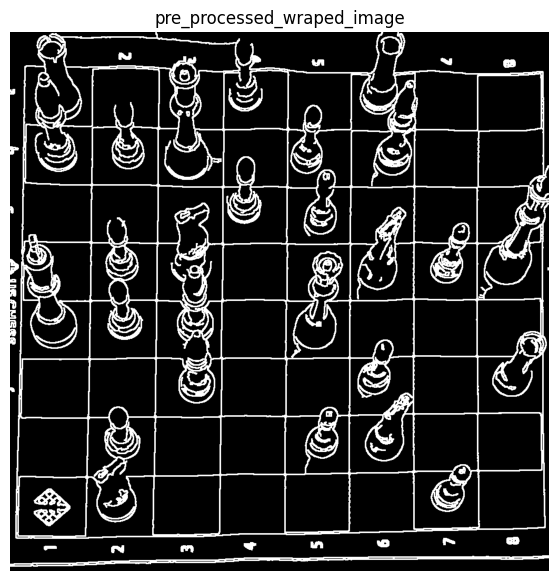

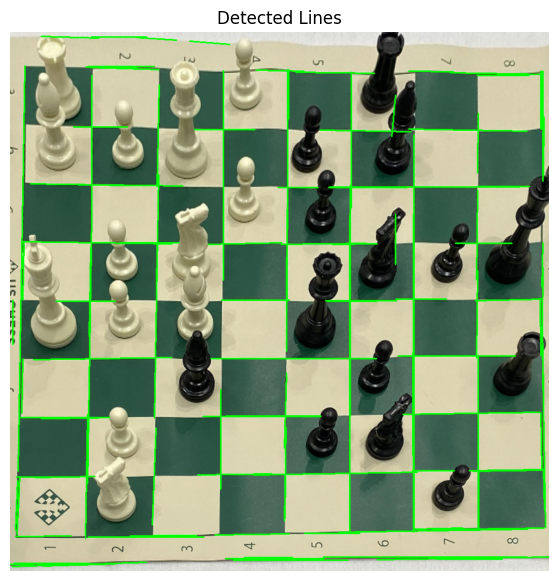

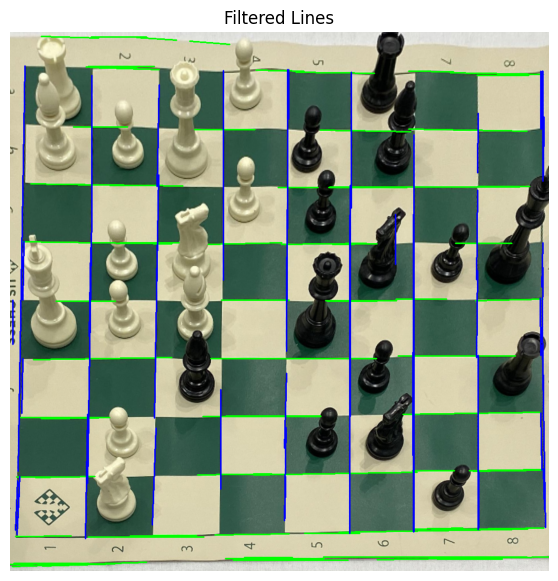

In [79]:
wrapped_image_processed = pre_processing_pipeline(wrapped_image, threshold1=10, threshold2=150)
show_image_debug("pre_processed_wraped_image", wrapped_image_processed)

wrapped_lines = detect_lines(wrapped_image_processed, hough_threshold=100, min_line_length=75, max_line_gap=3)
show_image_debug("Detected Lines", wrapped_image, Hlines=wrapped_lines)

wrapped_horizontal_lines, wrapped_vertical_lines = split_lines_hv(wrapped_lines, angle_tolerance_deg=5)
show_image_debug("Filtered Lines", wrapped_image, Hlines=wrapped_horizontal_lines, Vlines=wrapped_vertical_lines)


In [80]:
def collapse_and_average_lines(lines, dimension_index, grouping_threshold=15, num_lines=9):
    """
    Groups line segments that are close together and returns the mean position 
    for the top 'num_lines' groups.
    
    lines: The list/array of line segments (N, 4) in [x1, y1, x2, y2] format.
    dimension_index: 0 for vertical lines (checking X), 1 for horizontal lines (checking Y).
    grouping_threshold: Max pixel distance for lines to be considered the same (e.g., 15 pixels).
    num_lines: The expected final number of unique lines (must be 9 for a chessboard).
    """
    if len(lines) == 0:
        return np.array([])

    # 1. Calculate the position (P) for each line
    # P = Average of the coordinate in the specified dimension: (coord1 + coord2) / 2
    # For Vertical (index 0): P = (x1 + x2) / 2
    # For Horizontal (index 1): P = (y1 + y2) / 2
    positions = (lines[:, dimension_index] + lines[:, dimension_index + 2]) / 2
    
    # 2. Combine position with the original line for sorting
    combined = np.hstack((positions.reshape(-1, 1), lines))
    
    # 3. Sort primarily by position (X or Y)
    combined = combined[combined[:, 0].argsort()]
    
    # 4. Collapse/Cluster Lines
    final_positions = []
    current_cluster = []
    
    if len(combined) > 0:
        # Start the first cluster
        current_cluster.append(combined[0, 0])
        
        for i in range(1, len(combined)):
            current_pos = combined[i, 0]
            last_pos_in_cluster = current_cluster[-1]
            
            # If the current line is close to the last one in the cluster, add it
            if np.abs(current_pos - last_pos_in_cluster) < grouping_threshold:
                current_cluster.append(current_pos)
            else:
                # New cluster starts: Average the old cluster and save the position
                final_positions.append(np.mean(current_cluster))
                current_cluster = [current_pos]
        
        # Don't forget the final cluster
        if current_cluster:
            final_positions.append(np.mean(current_cluster))

    # 5. Optional: Enforce 9 lines
    # If more than 9 lines are found, this likely means the threshold was too small.
    # We take the top 9 most distinct lines based on the initial clustering.
    if len(final_positions) != num_lines:
        print(f"Warning: Found {len(final_positions)} clusters, expected {num_lines}. Check 'grouping_threshold'.")
        # If we found too many, take the 9 widest spread clusters
        if len(final_positions) > num_lines:
             # Simplest way: just take the first 9 unique positions, but better would be to re-cluster
             # For now, we rely on the next step (Regularization) to fix missing lines.
             pass

    # Return the mean positions (e.g., 9 distinct X coordinates or 9 distinct Y coordinates)
    return np.array(final_positions, dtype=np.float32)


def get_ideal_line_positions(h_lines, v_lines, threshold=15):
    """
    Wrapper function to apply clustering to both horizontal and vertical lines.
    """
    # Vertical lines: We look at the X-coordinate (index 0)
    ideal_x_positions = collapse_and_average_lines(
        v_lines, 
        dimension_index=0, 
        grouping_threshold=threshold
    )
    
    # Horizontal lines: We look at the Y-coordinate (index 1)
    ideal_y_positions = collapse_and_average_lines(
        h_lines, 
        dimension_index=1, 
        grouping_threshold=threshold
    )
    
    return ideal_x_positions, ideal_y_positions

In [81]:


def filter_redundant_lines_no_averaging(positions, grid_size=9):
    """
    Filters redundant line positions until the desired number of lines (grid_size) 
    is reached. It prioritizes the removal of lines closest to a neighbor. 
    It includes a specific tie-breaker to handle noisy edge lines, prioritizing 
    their removal when they are part of the tightest cluster.

    Args:
        positions (list or np.ndarray): A sorted list of line positions (coordinates).
        grid_size (int): The target number of lines to retain.

    Returns:
        np.ndarray: The filtered and sorted array of line positions.
    """
    positions = np.array(sorted(positions), dtype=float)
    
    if len(positions) <= grid_size:
        return positions
    
    while len(positions) > grid_size:
        
        # 1. Calculate Gaps L and R
        N = len(positions)
        max_dist = positions[-1] - positions[0]
        large_dist = max_dist * 2.0
        
        # Distance to the left neighbor (previous element)
        dist_to_left = np.insert(np.diff(positions), 0, large_dist)
        
        # Distance to the right neighbor (next element)
        dist_to_right = np.append(np.diff(positions), large_dist)

        # 2. Determine Redundancy Score (Minimum Distance to Nearest Neighbor)
        distance_to_nearest_neighbor = np.minimum(dist_to_left, dist_to_right)
        
        # Find the minimum distance (the smallest gap)
        min_dist = np.min(distance_to_nearest_neighbor)
        
        # Find all indices that are part of the tightest cluster
        indices_to_consider = np.where(distance_to_nearest_neighbor == min_dist)[0]
        
        # 3. Tie-Breaker Strategy (Prioritize Edge/Largest Gap)
        
        remove_index = -1
        
        # 3a. Check for boundary line candidates (P0 or PN-1)
        if 0 in indices_to_consider:
            # If the first line is part of the tightest cluster, remove it.
            remove_index = 0
        elif (N - 1) in indices_to_consider:
            # If the last line is part of the tightest cluster, remove it.
            remove_index = N - 1
        
        # 3b. If no boundary line was selected, use the "largest new gap" heuristic 
        # (most centered) for the remaining tied internal lines.
        if remove_index == -1:
            # Filter the list to only include internal tied lines
            tied_internal_indices = indices_to_consider
            
            # Calculate the new gap created for these tied lines
            gap_if_removed = dist_to_left[tied_internal_indices] + dist_to_right[tied_internal_indices]

            # The index within the tied_internal_indices array that maximizes the new gap
            max_gap_tied_index = np.argmax(gap_if_removed)
            
            # The final index in the original positions array to remove
            remove_index = tied_internal_indices[max_gap_tied_index]

        # 4. Remove the line
        positions = np.delete(positions, remove_index)

    return positions

def create_drawing_lines(positions, dimension_index, image_width, image_height):
    """
    Converts a 1D array of mean positions (X or Y) into a 2D array of 
    [x1, y1, x2, y2] segments that span the image.
    """
    drawing_lines = []
    
    for pos in positions:
        pos = int(pos)
        if dimension_index == 1: # Horizontal line (Y-position)
            # Create a line from (0, Y_pos) to (Width, Y_pos)
            line_segment = [0, pos, image_width, pos]
        elif dimension_index == 0: # Vertical line (X-position)
            # Create a line from (X_pos, 0) to (X_pos, Height)
            line_segment = [pos, 0, pos, image_height]
        
        drawing_lines.append(line_segment)
        
    return np.array(drawing_lines, dtype=np.float32)

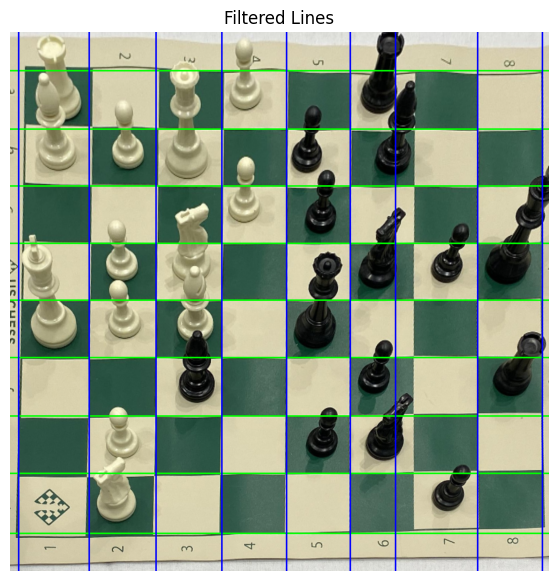

In [82]:
h, w = wrapped_image.shape[:2]

c_wrapped_horizontal_pos = collapse_and_average_lines(
    wrapped_horizontal_lines, 
    dimension_index=1, 
    grouping_threshold=15
)
c_wrapped_vertical_pos = collapse_and_average_lines(
    wrapped_vertical_lines, 
    dimension_index=0, 
    grouping_threshold=15
)

final_y_pos = filter_redundant_lines_no_averaging(c_wrapped_horizontal_pos)
final_x_pos = filter_redundant_lines_no_averaging(c_wrapped_vertical_pos)

final_h_lines = create_drawing_lines(final_y_pos, 1, w, h)
final_v_lines = create_drawing_lines(final_x_pos, 0, w, h)


show_image_debug("Filtered Lines", wrapped_image, Hlines=final_h_lines, Vlines=final_v_lines)


In [83]:
def generate_final_grid_points(final_x_pos, final_y_pos, grid_size=9):
    """
    Creates the final (9, 9, 2) grid matrix from the set of perfect X and Y coordinates.
    
    final_x_pos: 1D array of 9 unique X coordinates (vertical line positions).
    final_y_pos: 1D array of 9 unique Y coordinates (horizontal line positions).
    """
    
    if len(final_x_pos) != grid_size or len(final_y_pos) != grid_size:
        print(f"Error: Expected {grid_size} positions in each dimension, found {len(final_x_pos)} and {len(final_y_pos)}.")
        return None

    # 1. Use itertools.product to generate all (X, Y) pairs
    # Note: We iterate Y first (rows) then X (columns) to match common matrix notation (Row, Column)
    all_points = []
    
    # Iterate through all Y positions (rows)
    for y in final_y_pos:
        # Iterate through all X positions (columns)
        for x in final_x_pos:
            all_points.append([x, y])
            
    # 2. Convert to a structured NumPy array
    # The result is a (9, 9, 2) matrix where result[i, j] = [x, y]
    final_grid_matrix = np.array(all_points, dtype=np.float32).reshape(grid_size, grid_size, 2)
    
    return final_grid_matrix

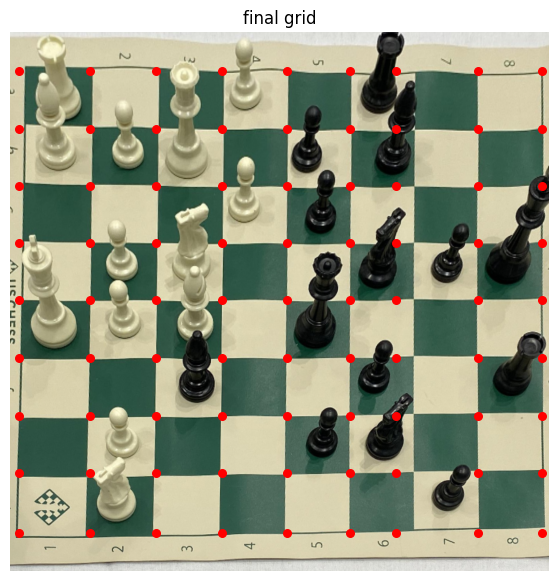

In [84]:
final_grid = generate_final_grid_points(final_x_pos,final_y_pos)
flat_points_array = final_grid.reshape(-1, 2)
show_image_debug("final grid",wrapped_image,points=flat_points_array)
